In [2]:
import numpy as np
import cv2 as cv2
import matplotlib.pyplot as plt
import pandas as pd

## LIBRARY

Library numpy untuk operasi numerik dan manipulasi array citra, cv2 untuk pemrosesan citra digital, matplotlib.pyplot untuk visualisasi citra dan histogram, serta pandas untuk pengolahan data, yang secara keseluruhan menjadi dasar dalam pengolahan citra digital terutama dalam manipulasi piksel dan analisis data.

Mnempilkan citra dalam Grayscale

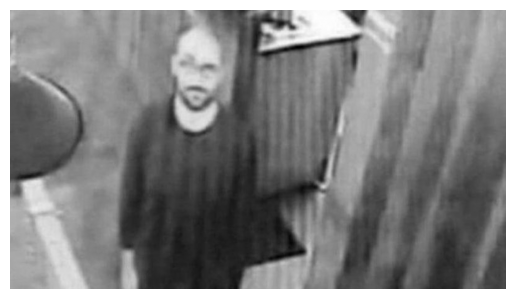

In [4]:
def show(img, title=""):
    plt.imshow(img, cmap='gray')
    plt.title(title)  
    plt.axis('off')

backup = plt.imread("backup.jpg")
img_gray = cv2.cvtColor(backup, cv2.COLOR_RGB2GRAY)
if img_gray.dtype != np.uint8:
    img_gray = (img_gray * 255).astype(np.uint8)

show(img_gray)

## SMOOTHING, SHARPENING, DAN KOMBINASI
## Apakah Perbedaan Antara ke-3 metode tersebut? Jelaskan kegunaan dan perbedaanya!
Smoothing: menghaluskan citra dengan merata-ratakan nilai pixel di sekitarnya sehingga noise berkurang namun detail tepi menjadi melemah. 

Sharpening: mempertajam tepi dan detail citra dengan memperkuat perbedaan antar pixel menggunakan nilai negatif di sekitar kernel.

Smoothing + Sharpening: citra dihaluskan terlebih dahulu untuk mengurangi noise, kemudian dipertajam kembali untuk menonjolkan tepi, sehingga hasilnya lebih bersih sekaligus tetap tajam.

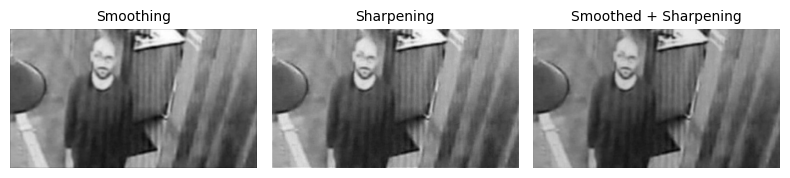

In [17]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
            
    return canvas

kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5, 1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np.array([
    [-1/9, -1/9, -1/9],
    [-1/9, 17/9, -1/9],
    [-1/9, -1/9, -1/9]
])

img_smoothed = convolution(img_gray, kernelSmoothing)
img_sharpened = np.clip(convolution(img_gray, kernelSharpening), 0, 255).astype(np.uint8)
img_smootedsharpened = convolution(img_smoothed, kernelSharpening)

plt.figure(figsize=(8,8))

plt.subplot(1,3,1)
plt.imshow(img_smoothed, cmap='gray')
plt.title('Smoothing', fontsize=10)
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_sharpened, cmap='gray')
plt.title('Sharpening', fontsize=10)
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img_smootedsharpened, cmap='gray')
plt.title('Smoothed + Sharpening', fontsize=10)
plt.axis('off')

plt.tight_layout()
plt.show()

## MEAN, MEDIAN, MODUS
## Apa Perbedaan Hasil dari Mean, Median dan Modus?
Mean menghasilkan citra yang sedikit lebih blur dan halus merata karena nilai pixel digantikan oleh rata-rata seluruh area kernel. 

Median menghasilkan citra yang sedikit lebih tajam dibanding Mean karena nilai tengah lebih tahan terhadap pixel ekstrem, sehingga tepi objek lebih terjaga. 

Modus menghasilkan citra yang cenderung datar di area warna seragam karena nilai yang paling sering muncul mendominasi, namun pada area dengan variasi warna tinggi hasilnya bisa kurang halus. Perbedaan ketiganya akan jauh lebih terlihat jika citra mengandung banyak noise atau kernel diperbesar.

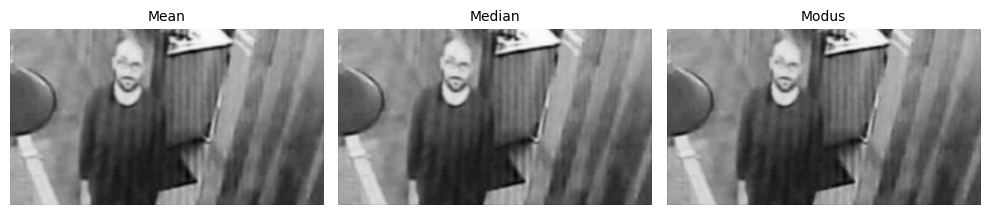

In [18]:
def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)

    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    canvas[i, j] = np.sum(region) // area

        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = np.sort(region.ravel())
                    canvas[i, j] = values[len(values) // 2]

        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    canvas[i, j] = mode_val

    return canvas

img_smoothedsharpened = np.clip(img_smootedsharpened, 0, 255).astype(np.uint8)

img_mean = filter(img_smoothedsharpened, 3, 'mean')
img_median = filter(img_smoothedsharpened, 3, 'median')
img_modus = filter(img_smoothedsharpened, 3, 'modus')

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_mean, cmap='gray')
plt.title('Mean', fontsize=10)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_median, cmap='gray')
plt.title('Median', fontsize=10)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_modus, cmap='gray')
plt.title('Modus', fontsize=10)
plt.axis('off')

plt.tight_layout()
plt.show()

## DETEKSI TEPI DAN KOMBINASI OPERATOR
## Jelaskan kegunaan operator dan kombinasi dari operator-operator tersebut!
Sobel untuk mendeteksi tepi horizontal dan vertikal karena memberikan bobot lebih pada pixel di tengah, sehingga hasilnya lebih halus. Prewitt mirip dengan Sobel tapi bobotnya merata, hasilnya hampir sama namun sedikit lebih sensitif terhadap noise. Roberts menggunakan area yang lebih kecil (2×2) dan lebih fokus mendeteksi tepi diagonal, tapi karena areanya kecil dia lebih mudah terpengaruh noise.

Prewitt + Sobel menggabungkan dua operator yang sama-sama kuat di tepi horizontal dan vertikal, sehingga tepi di kedua arah tersebut terlihat lebih tebal dan jelas. Prewitt + Roberts memadukan kekuatan Prewitt di tepi horizontal dan vertikal dengan kemampuan Roberts menangkap tepi diagonal, sehingga cakupan arah tepi yang terdeteksi menjadi lebih luas. Sobel + Roberts menghasilkan efek serupa dengan Prewitt + Roberts, namun tepi horizontal dan vertikalnya terlihat sedikit lebih halus karena Sobel lebih tahan noise dibanding Prewitt. Kombinasi ketiganya (Prewitt + Sobel + Roberts) menghasilkan deteksi tepi yang paling lengkap karena mencakup semua arah sekaligus (horizontal, vertikal, dan diagonal) meskipun hasilnya juga paling ramai karena semua perubahan intensitas ikut terdeteksi.

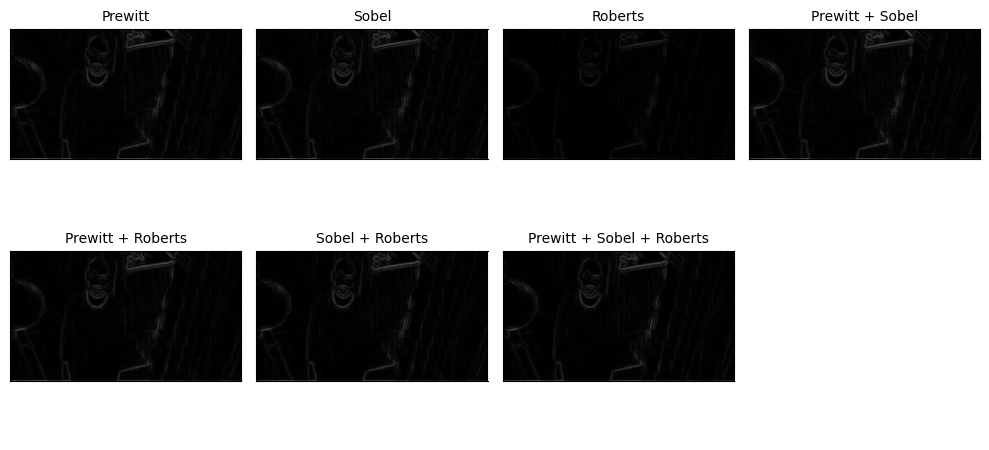

In [61]:
sobelx = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobely = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

prewittx = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewitty = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)

robertsx = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

robertsy = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)

def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np.abs(gx) + np.abs(gy)
    if np.max(canvas) > 0:
        canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

def combine_edges(*imgs):
    combined = np.zeros_like(imgs[0], dtype=np.float32)
    for img in imgs:
        combined += img.astype(np.float32)
    combined = combined * 255.0 / np.max(combined)
    return np.clip(combined, 0, 255).astype(np.uint8)

base = img_smoothedsharpened

prewitt = edge(base, prewittx, prewitty)
sobel = edge(base, sobelx, sobely)
roberts = edge(base, robertsx, robertsy)

roberts_boosted = np.clip(roberts.astype(np.float32) * 2.0, 0, 255).astype(np.uint8)

prewitt_sobel = combine_edges(prewitt, sobel)
prewitt_roberts = combine_edges(prewitt, roberts_boosted)
sobel_roberts = combine_edges(sobel, roberts_boosted)
prewitt_sobel_roberts = combine_edges(prewitt, sobel, roberts_boosted)

edge_results = [
    (prewitt, 'Prewitt'),
    (sobel, 'Sobel'),
    (roberts, 'Roberts'),
    (prewitt_sobel, 'Prewitt + Sobel'),
    (prewitt_roberts, 'Prewitt + Roberts'),
    (sobel_roberts, 'Sobel + Roberts'),
    (prewitt_sobel_roberts, 'Prewitt + Sobel + Roberts'),
]

fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for ax, (img_res, title) in zip(axes.flatten(), edge_results):
    ax.imshow(img_res, cmap='gray')
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

axes.flatten()[-1].axis('off')

plt.tight_layout()
plt.show()

## TRESHOLD TEPI
## Jelaskan pengaruh penggunaan threshold. apa perbedaan mencolok dari threshold rendah dan tinggi? Berapa nilai Threshold paling bagus untuk kasus ini? berikan alasannya!

Pengaruhnya: semakin rendah nilai threshold, semakin banyak pixel yang lolos seleksi sehingga gambar terlihat lebih ramai dengan banyak garis tepi, termasuk noise dan detail kecil yang tidak penting. Sebaliknya semakin tinggi nilai threshold, semakin sedikit pixel yang lolos sehingga hanya tepi-tepi yang benar-benar kuat dan jelas yang tertampil, gambar pun terlihat lebih bersih namun berisiko kehilangan detail tepi yang penting.

Perbedaan paling mencolok terlihat pada threshold 10 vs threshold 60. Pada threshold 10 hampir seluruh area gambar menjadi putih karena hampir semua perubahan intensitas dianggap sebagai tepi, termasuk noise dan tekstur halus. Pada threshold 60 gambar hampir seluruhnya hitam dan hanya menyisakan garis tepi utama yang sangat kuat seperti kontur tubuh dan batas objek yang kontrasnya tinggi.

Untuk kasus ini, nilai threshold yang paling bagus adalah 20–30, karena ada tepi-tepi utama seperti kontur tubuh, wajah, dan objek di sekitarnya masih terlihat jelas dan cukup lengkap, namun noise dan detail yang tidak penting sudah mulai tersaring. Threshold di bawah 20 masih terlalu ramai dengan noise, sedangkan di atas 30 mulai kehilangan terlalu banyak informasi tepi yang berguna untuk identifikasi objek pada citra CCTV.

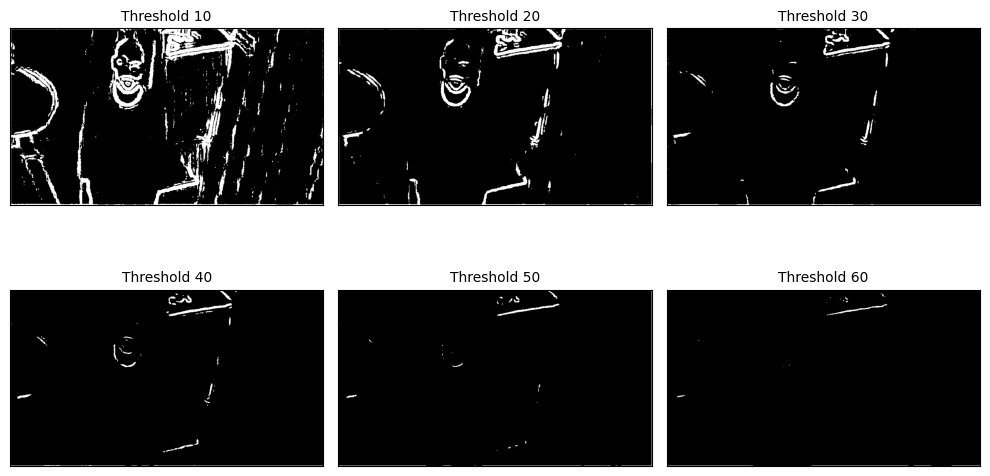

In [62]:
thresholds = [10, 20, 30, 40, 50, 60]

fig, axes = plt.subplots(2, 3, figsize=(10, 6))

for ax, thresh in zip(axes.flatten(), thresholds):
    binary = (prewitt_sobel_roberts > thresh).astype(np.uint8) * 255
    ax.imshow(binary, cmap='gray')
    ax.set_title(f'Threshold {thresh}', fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## HIGHLIGHT SILUET ORANG
Proses highlight siluet dilakukan dalam tiga tahap.

Pertama, dibuat binary mask dengan cara memisahkan area orang dari background berdasarkan nilai intensitas pixel, area gelap (orang) dijadikan putih dan sisanya hitam, lalu diperbaiki dengan morphological closing agar siluet lebih rapat.

Kedua, kontur terbesar dari mask diambil dan digambar sebagai outline putih di atas background hitam. 

Ketiga, area dalam mask diwarnai kuning dan digabungkan dengan gambar asli sebagai overlay transparan sehingga objek orang lebih mudah diidentifikasi. 

Tantangan utamanya adalah warna orang yang mirip dengan background CCTV yang gelap, sehingga area deteksi perlu dibatasi secara manual agar objek lain tidak ikut terdeteksi.

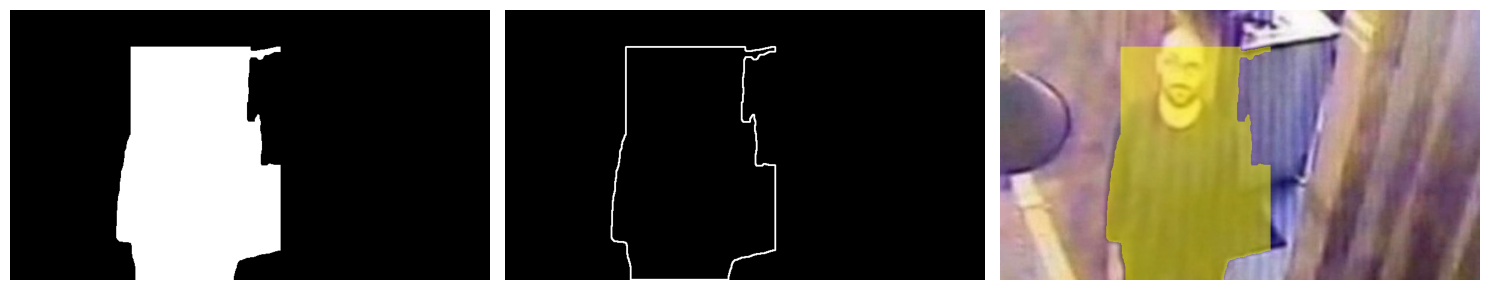

In [79]:
blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)

_, mask_body = cv2.threshold(blurred, 100, 255, cv2.THRESH_BINARY_INV)
_, mask_face = cv2.threshold(blurred, 100, 255, cv2.THRESH_BINARY)

mask_face[:, 0:200] = 0
mask_face[:, 360:] = 0
mask_face[0:60, :] = 0
mask_face[200:, :] = 0

binary_mask = cv2.bitwise_or(mask_body, mask_face)

binary_mask[:, 0:130] = 0
binary_mask[:, 450:] = 0
binary_mask[0:60, :] = 0

kernel = np.ones((10, 10), np.uint8)
binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)
binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))

contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest = max(contours, key=cv2.contourArea)

mask_filled = np.zeros_like(img_gray)
cv2.drawContours(mask_filled, [largest], -1, 255, thickness=cv2.FILLED)

contour_img = np.zeros_like(img_gray)
cv2.drawContours(contour_img, [largest], -1, 255, thickness=2)

highlight = backup.copy()
yellow_overlay = highlight.copy()
yellow_overlay[mask_filled == 255] = [255, 255, 0]
highlight = cv2.addWeighted(highlight, 0.5, yellow_overlay, 0.5, 0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(mask_filled, cmap='gray')
axes[0].axis('off')

axes[1].imshow(contour_img, cmap='gray')
axes[1].axis('off')

axes[2].imshow(highlight)
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Pas Foto: Deteksi Tepi dan Background Removal
Proses pada citra pas foto david.jpg dilakukan dalam dua bagian utama. Pertama adalah deteksi tepi, karena pencahayaan pas foto lebih baik dan merata dibanding CCTV, tepi wajah, rambut, dan pakaian bisa terdeteksi dengan lebih jelas dan bersih menggunakan operator Sobel. Gambar diblur terlebih dahulu untuk mengurangi noise tekstur kulit sebelum deteksi tepi dilakukan, sehingga hasilnya hanya menampilkan garis tepi yang benar-benar signifikan.

Bagian kedua adalah background removal. Karena background pas foto berwarna toska yang khas, pemisahan foreground dan background dilakukan dengan membandingkan nilai kanal RGB. Background toska memiliki nilai kanal biru (B) dan hijau (G) yang jauh lebih tinggi dari kanal merah (R). Pixel yang memenuhi kondisi tersebut diklasifikasikan sebagai background lalu diganti menjadi putih, sedangkan area foreground (orang) dipertahankan apa adanya. Pendekatan ini jauh lebih mudah dan akurat dibanding citra CCTV karena warna background dan foreground memiliki perbedaan yang sangat jelas.

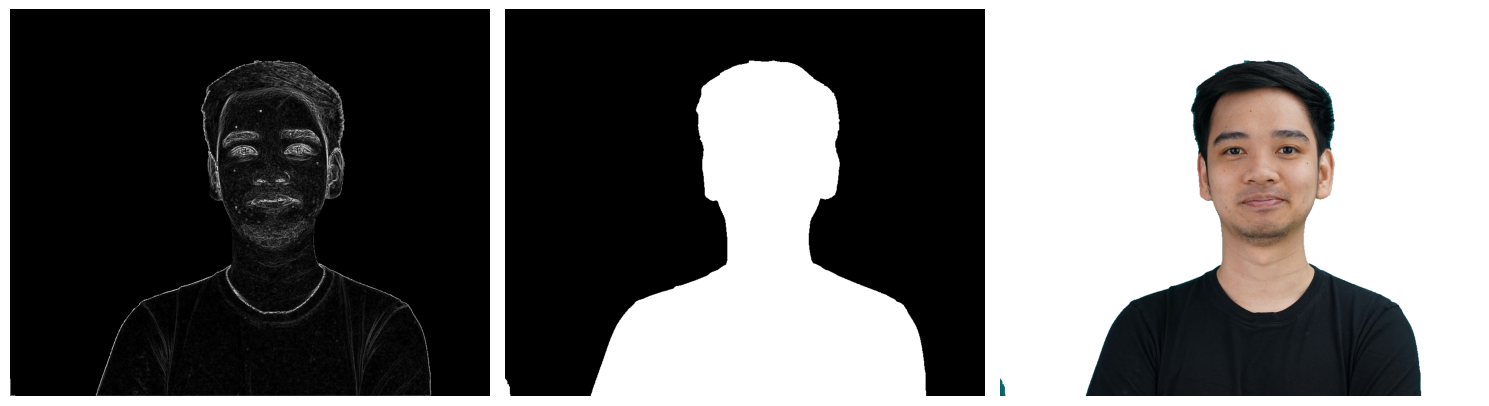

In [84]:
david = plt.imread("david.jpg")

david_gray = cv2.cvtColor(david, cv2.COLOR_RGB2GRAY)

sobelx_d = convolution(david_gray.astype(np.float32), sobelx)
sobely_d = convolution(david_gray.astype(np.float32), sobely)
david_edge = np.abs(sobelx_d) + np.abs(sobely_d)
david_edge = (david_edge * 255.0 / np.max(david_edge)).astype(np.uint8)
david_edge = (david_edge * 3).clip(0, 255).astype(np.uint8)
david_edge[fg_mask == 0] = 0

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(david_edge, cmap='gray')
axes[0].axis('off')

axes[1].imshow(fg_mask, cmap='gray')
axes[1].axis('off')

axes[2].imshow(result)
axes[2].axis('off')

plt.tight_layout()
plt.show()

## ANALISIS DAN KESIMPULAN

Dari praktikum ini dapat disimpulkan bahwa perbaikan kualitas citra dan deteksi tepi adalah dua proses yang saling melengkapi dalam pengolahan citra digital. Perbaikan kualitas seperti smoothing dan sharpening sangat penting dilakukan sebelum deteksi tepi. Tanpa smoothing, noise akan ikut terdeteksi sebagai tepi palsu, dan tanpa sharpening detail tepi yang lemah bisa terlewat. Pemilihan filter yang tepat juga bergantung pada kondisi gambar, seperti median filter yang lebih cocok untuk gambar dengan noise salt-and-pepper, atau mean filter untuk noise yang lebih merata.

Deteksi tepi sendiri terbukti berguna untuk mengekstrak informasi penting dari gambar seperti kontur objek, batas area, dan bentuk subjek. Kombinasi beberapa operator deteksi tepi menghasilkan hasil yang lebih lengkap dibanding satu operator saja. Selain itu, kualitas gambar input sangat menentukan hasil akhir serta gambar CCTV yang gelap dan berkontras rendah jauh lebih sulit diproses dibanding pas foto dengan pencahayaan yang baik dan background yang seragam. Hal ini menunjukkan bahwa dalam aplikasi nyata seperti keamanan atau identifikasi forensik, kualitas gambar awal adalah faktor yang sangat krusial.